In [1]:
! pip install shap

! pip install ipywidgets

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

import shap

import matplotlib.pyplot as plt

In [3]:
data = fetch_california_housing()
X = data.data
y = data.target

In [4]:
feature_names = data.feature_names

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [7]:
explainer = shap.TreeExplainer(model)

Pick one instance to explain:

In [8]:
i = 0
instance = X_test[i]

In [9]:
shap_values = explainer.shap_values(instance)

In [10]:
print("Prediction:", model.predict(instance.reshape(1, -1)))

Prediction: [1.76546]


In [11]:
print("\nSHAP values:")
for name, val in zip(feature_names, shap_values):
    print(f"{name}: {val:.4f}")


SHAP values:
MedInc: -0.6416
HouseAge: 0.1114
AveRooms: -0.0484
AveBedrms: 0.1174
Population: -0.0074
AveOccup: -0.1870
Latitude: 0.3552
Longitude: 0.0018


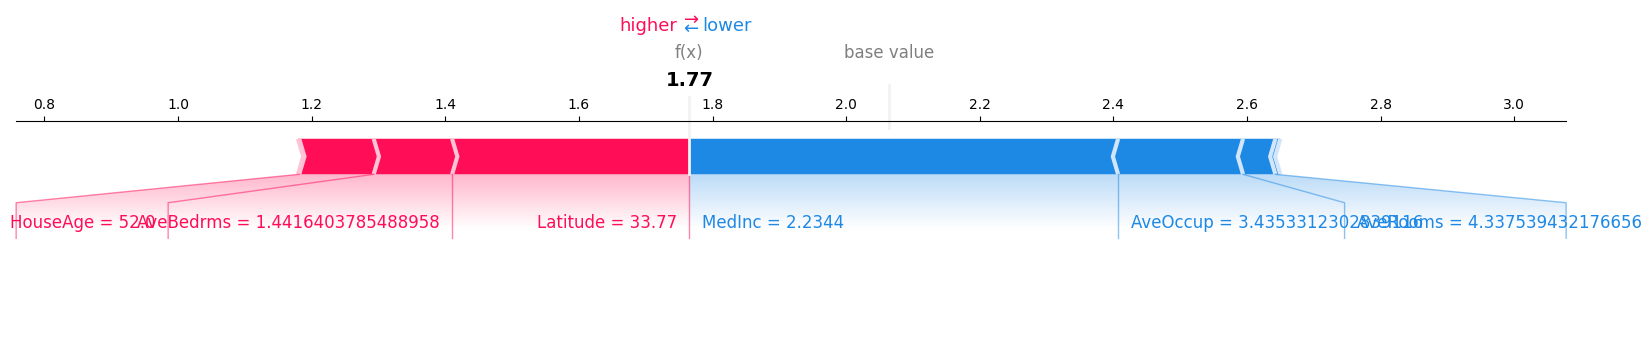

In [12]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values,
    instance,
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

In [13]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

i = 0
instance = X_test[i]
true_label = y_test[i]

print("True label:", class_names[true_label])
print("Prediction:", class_names[model.predict(instance.reshape(1, -1))[0]])

True label: benign
Prediction: benign


In [14]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (114, 30, 2)


local explanation:

In [15]:
i = 0
print("True label:", class_names[y_test[i]])
pred = model.predict(X_test[i].reshape(1, -1))[0]
print("Predicted:", class_names[pred])

True label: benign
Predicted: benign


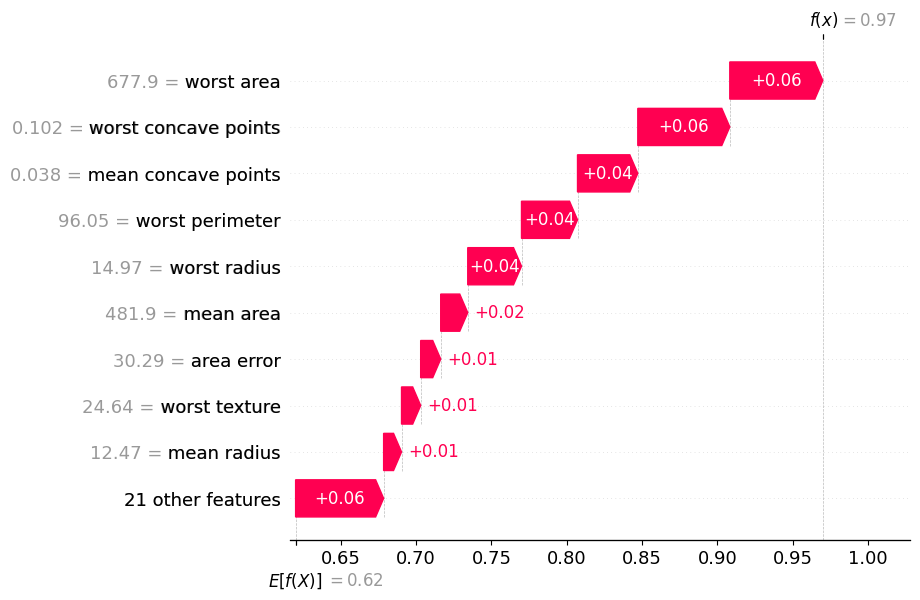

In [16]:
shap_values.feature_names = feature_names
shap.plots.waterfall(shap_values[i, :, pred])

global explanation:

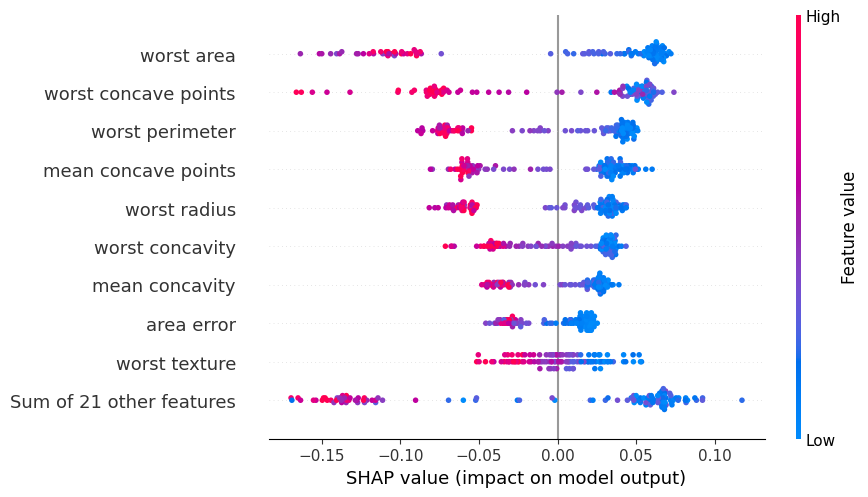

In [17]:
class_idx = 1
shap.plots.beeswarm(shap_values[:, :, class_idx])